In [1]:
import pandas as pd

df = pd.read_csv('orders_raw.csv')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [2]:
df.columns = df.columns.str.strip().str.lower()

In [3]:
import numpy as np

df['rating'] = np.where(df['delivery_time_min'] <= 25, 5,
                np.where(df['delivery_time_min'] <= 40, 4,
                np.where(df['delivery_time_min'] <= 55, 3, 2)))

In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                1000 non-null   int64  
 1   distance_km             1000 non-null   float64
 2   weather                 970 non-null    object 
 3   traffic_level           970 non-null    object 
 4   time_of_day             970 non-null    object 
 5   vehicle_type            1000 non-null   object 
 6   preparation_time_min    1000 non-null   int64  
 7   courier_experience_yrs  970 non-null    float64
 8   delivery_time_min       1000 non-null   int64  
 9   rating                  1000 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


,order_id,distance_km,preparation_time_min,courier_experience_yrs,delivery_time_min,rating
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000,1000.00000
mean,500.500000,10.059970,16.982000,4.579381,56.732000,2.80600
std,288.819436,5.696656,7.204553,2.914394,22.070915,0.94194
min,1.000000,0.590000,5.000000,0.000000,8.000000,2.00000
25%,250.750000,5.105000,11.000000,2.000000,41.000000,2.00000
50%,500.500000,10.190000,17.000000,5.000000,55.500000,2.50000
75%,750.250000,15.017500,23.000000,7.000000,71.000000,3.00000
max,1000.000000,19.990000,29.000000,9.000000,153.000000,5.00000


In [5]:
# Remove nulls
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [6]:
import numpy as np

# Delay flag
df['is_delayed'] = df['delivery_time_min'] > 40

# Time category
df['time_slot'] = pd.cut(df['delivery_time_min'],
                         bins=[0, 25, 40, 60],
                         labels=['Fast', 'Normal', 'Late'])

# Customer type (your addition)
df['customer_type'] = np.random.choice(['New', 'Returning'], size=len(df))

In [8]:
df.to_csv('orders_cleaned.csv', index=False)

In [9]:
df.groupby('is_delayed')['rating'].mean()

is_delayed
False    4.231818
True     2.336350
Name: rating, dtype: float64

In [10]:
df.groupby('traffic_level')['delivery_time_min'].mean()

traffic_level
High      64.298343
Low       52.498559
Medium    56.250704
Name: delivery_time_min, dtype: float64

In [11]:
df.groupby('weather')['delivery_time_min'].mean()

weather
Clear    52.668235
Foggy    59.663265
Rainy    59.095745
Snowy    66.813953
Windy    55.081395
Name: delivery_time_min, dtype: float64

In [12]:
df.groupby('courier_experience_yrs')['delivery_time_min'].mean()

courier_experience_yrs
0.0    60.337349
1.0    58.750000
2.0    54.351648
3.0    59.000000
4.0    58.975610
5.0    53.831325
6.0    56.368932
7.0    56.439024
8.0    53.347368
9.0    54.205882
Name: delivery_time_min, dtype: float64

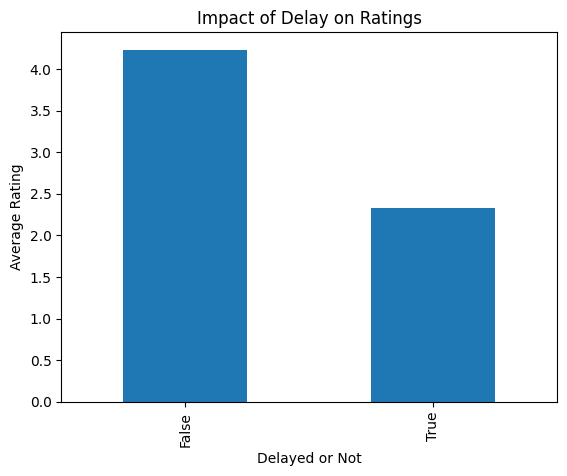

In [13]:
import matplotlib.pyplot as plt

df.groupby('is_delayed')['rating'].mean().plot(kind='bar')
plt.title("Impact of Delay on Ratings")
plt.xlabel("Delayed or Not")
plt.ylabel("Average Rating")
plt.show()

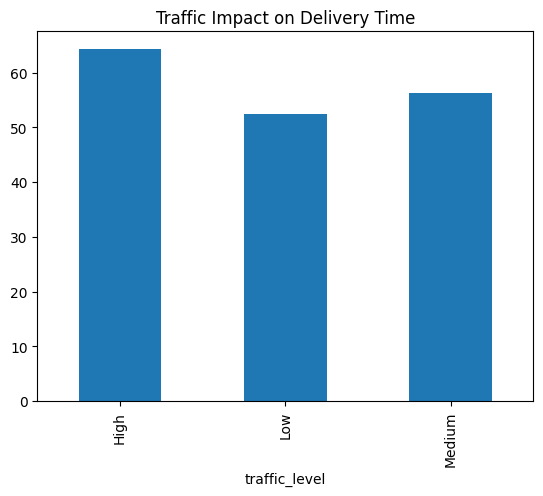

In [14]:
df.groupby('traffic_level')['delivery_time_min'].mean().plot(kind='bar')
plt.title("Traffic Impact on Delivery Time")
plt.show()